# ***Online News Popularity Project***

##### ***Name*** : _Allen Daniel Raju_
##### ***Batch*** :  _DSML - D53_ 
##### ***Organization*** : _Entri Elevate Coding_
##### ***Date*** : _18-04-2025_

<img src="online pp.webp">

## **Introduction**

The rise of digital media has transformed how people consume news, making social engagement a critical factor in determining an article’s success. This project aims to analyze and predict the popularity of online news articles based on various factors, such as textual attributes, metadata, and social interactions. Using machine learning techniques, we assess how different features influence the Rating an article receives, providing valuable insights for content creators and media platforms.

## **Objective**

The main objective of this project is to build an accurate and interpretable machine learning model that predicts article popularity based on its features. To achieve this, we focus on:

✅ Data Preprocessing: Cleaning the dataset by handling missing values, detecting and treating outliers, and addressing skewness.

✅ Feature Engineering: Identifying the most relevant features that impact article popularity.

✅ Model Selection & Evaluation: Training multiple machine learning models, optimizing hyperparameters, and selecting the best-performing model.

✅ Predictions on New Data: Applying the trained model to unseen articles to predict their expected engagement.

This project will help media companies, journalists, and marketers optimize content strategies by understanding the key drivers behind highly shared news articles.

## **Data Description**

🟢 Source: _UCI Machine Learning Repository_

🟢 _Lets breakdown each column_

The dataset includes various features influencing article ratings, such as:

✅ Text-Based Features – Word count, title length, keywords.

✅ Visual Content – Number of images and videos in the article.

✅ Publication Details – Day of the week, publishing time.

✅ Engagement Metrics – Social media shares.


_The dataset is a 24.31 MB csv file containing 39,644 instances with 61 attributes. Given that there are 61 attributes, I included detailed attribute descriptions in my repo and an excerpt below._

1. url: URL of the article (non-predictive)

2. timedelta: Days between the article publication and the dataset acquisition (non-predictive)

3. n_tokens_title: Number of words in the title

4. n_tokens_content: Number of words in the content

5. n_unique_tokens: Rate of unique words in the content

6. n_non_stop_words: Rate of non-stop words in the content

7. n_non_stop_unique_tokens: Rate of unique non-stop words in the content

8. num_hrefs: Number of links

9. num_self_hrefs: Number of links to other articles published by Mashable

10. num_imgs: Number of images

11. num_videos: Number of videos

12. average_token_length: Average length of the words in the content

13. num_keywords: Number of keywords in the metadata

14. data_channel_is_lifestyle: Is data channel 'Lifestyle'?

15. data_channel_is_entertainment: Is data channel 'Entertainment'?

16. data_channel_is_bus: Is data channel 'Business'?

17. data_channel_is_socmed: Is data channel 'Social Media'?

18. data_channel_is_tech: Is data channel 'Tech'?

19. data_channel_is_world: Is data channel 'World'?

20. kw_min_min: Worst keyword (min. shares)

21. kw_max_min: Worst keyword (max. shares)

22. kw_avg_min: Worst keyword (avg. shares)

23. kw_min_max: Best keyword (min. shares)

24. kw_max_max: Best keyword (max. shares)

25. kw_avg_max: Best keyword (avg. shares)

26. kw_min_avg: Avg. keyword (min. shares)

27. kw_max_avg: Avg. keyword (max. shares)

28. kw_avg_avg: Avg. keyword (avg. shares)

29. self_reference_min_shares: Min. shares of referenced articles in Mashable

30. self_reference_max_shares: Max. shares of referenced articles in Mashable

31. self_reference_avg_sharess: Avg. shares of referenced articles in Mashable

32. weekday_is_monday: Was the article published on a Monday?

33. weekday_is_tuesday: Was the article published on a Tuesday?

34. weekday_is_wednesday: Was the article published on a Wednesday?

35. weekday_is_thursday: Was the article published on a Thursday?

36. weekday_is_friday: Was the article published on a Friday?

37. weekday_is_saturday: Was the article published on a Saturday?

38. weekday_is_sunday: Was the article published on a Sunday?

39. is_weekend: Was the article published on the weekend?

40. LDA_00: Closeness to LDA topic 0 (linear discriminant analysis)

41. LDA_01: Closeness to LDA topic 1

42. LDA_02: Closeness to LDA topic 2

43. LDA_03: Closeness to LDA topic 3

44. LDA_04: Closeness to LDA topic 4

45. global_subjectivity: Text subjectivity

46. global_sentiment_polarity: Text sentiment polarity

47. global_rate_positive_words: Rate of positive words in the content

48. global_rate_negative_words: Rate of negative words in the content

49. rate_positive_words: Rate of positive words among non-neutral tokens

50. rate_negative_words: Rate of negative words among non-neutral tokens

51. avg_positive_polarity: Avg. polarity of positive words

52. min_positive_polarity: Min. polarity of positive words

53. max_positive_polarity: Max. polarity of positive words

54. avg_negative_polarity: Avg. polarity of negative words

55. min_negative_polarity: Min. polarity of negative words

56. max_negative_polarity: Max. polarity of negative words

57. title_subjectivity: Title subjectivity

58. title_sentiment_polarity: Title polarity

59. abs_title_subjectivity: Absolute subjectivity level

60. abs_title_sentiment_polarity: Absolute polarity level

61. shares: Number of shares

### Data Collection

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('OnlineNewsPopularity.csv')
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [3]:
# data types for each attribute
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [4]:
df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


### Data Cleaning

In [5]:
# remove leading spaces from attribute names
# this clean up will make it easier to write code with column names
df.columns = df.columns.str.strip()

In [6]:
# check for null values to determine if attributes need to be dropped or filled in
df.isnull().values.any()

False

In [7]:
# check for duplicates to determine if rows need to be deleted to avoid double counting
df.drop_duplicates()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,...,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,...,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,...,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,...,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100


In [8]:
# drop non-predictive attributes as these attributes will not contribute to analysis
# URL - URL of the article
# timedelta - Days between the article publication and the dataset acquisition

# drop is_weekend as there are separate attributes for Saturday and Sunday (this attribute is redundant)

df.drop(labels=['url', 'timedelta', 'is_weekend'], axis = 1, inplace=True)
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [9]:
# Create a dictionary mapping column names to labels
column_labels = {
    'data_channel_is_lifestyle': 'lifestyle',
    'data_channel_is_entertainment': 'entertainment',
    'data_channel_is_bus': 'bus',
    'data_channel_is_socmed': 'socmed',
    'data_channel_is_tech': 'tech',
    'data_channel_is_world': 'world'
}

# Create a new column for labels based on the channel columns
df['data_channel'] = df[[col for col in column_labels.keys()]].apply(
    lambda row: column_labels[row.idxmax()] if row.max() == 1 else 'other', axis=1
)

# Drop the original channel columns
df.drop(list(column_labels.keys()), axis=1, inplace=True)
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,data_channel
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,entertainment
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,bus
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,bus
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,entertainment
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,tech


In [10]:
# Create a dictionary mapping column names to labels
column_labels = {
    'weekday_is_monday': 'monday',
    'weekday_is_tuesday': 'tuesday',
    'weekday_is_wednesday': 'wednesday',
    'weekday_is_thursday': 'thursday',
    'weekday_is_friday': 'friday',
    'weekday_is_saturday': 'saturday',
    'weekday_is_sunday': 'sunday'
}

# Create a new column for labels based on the weekday columns
df['weekday_is'] = df[[col for col in column_labels.keys()]].apply(
    lambda row: column_labels[row.idxmax()] if row.max() == 1 else '', axis=1
)

# Drop the original weekday columns
df.drop(list(column_labels.keys()), axis=1, inplace=True)
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,data_channel,weekday_is
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,entertainment,monday
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,bus,monday
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,bus,monday
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,entertainment,monday
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,tech,monday


In [11]:
# n_tokens_content represents number of words in the content. It's min value is 0.
# This means that there are articles with no content.
# I'll remove these rows as it adds nothing to the analysis.

# find number of rows that contain 0 for n_tokens_content
num_no_content = df[df['n_tokens_content'] == 0].index
print('Number of articles with no content', num_no_content.size)

Number of articles with no content 1181


In [12]:
# delete rows with n_tokens_content = 0
df = df[df['n_tokens_content'] != 0]
print("Dataframe row count decreased from 39,644 to", len(df. index))

Dataframe row count decreased from 39,644 to 38463


#### Data cleaning summary up to this point:
- Removed leading spaces from attribute names
- Checked for null and duplicate values - values are unique and non-null
- Dropped 2 nonpredictive values and is_weekend attributes as these are unneccessary
- Reduced the number of attributes from 61 to 47 by combining like columns with binary numbers and changing the values to labels
- Removed articles with no content - reduced row count from 39,644 to 38,463

### Exploratory Data Analysis

In [13]:
# basic statistical descriptions of the data
df.describe()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,...,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000,38463.000000
mean,10.382419,563.295375,0.565049,1.027065,0.710336,11.217872,3.394769,4.563061,1.263786,4.687892,...,0.098376,0.779963,-0.267493,-0.537970,-0.110801,0.280573,0.070997,0.342431,0.154930,3355.360398
std,2.113800,468.299538,3.573022,5.307978,3.312293,11.340580,3.869773,8.295365,4.164896,0.283231,...,0.070382,0.212509,0.121174,0.279703,0.094919,0.323561,0.264338,0.188606,0.225636,11585.968776
min,2.000000,18.000000,0.114964,1.000000,0.119134,0.000000,0.000000,0.000000,0.000000,3.600000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,9.000000,259.000000,0.477419,1.000000,0.632588,5.000000,1.000000,1.000000,0.000000,4.496250,...,0.050000,0.600000,-0.331532,-0.714286,-0.125000,0.000000,0.000000,0.166667,0.000000,945.000000
50%,10.000000,423.000000,0.542986,1.000000,0.693727,8.000000,3.000000,1.000000,0.000000,4.674121,...,0.100000,0.800000,-0.257738,-0.500000,-0.100000,0.125000,0.000000,0.500000,0.000000,1400.000000
75%,12.000000,729.000000,0.611111,1.000000,0.756944,14.000000,4.000000,4.000000,1.000000,4.861901,...,0.100000,1.000000,-0.193415,-0.312500,-0.050000,0.500000,0.136364,0.500000,0.250000,2700.000000
max,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,8.041534,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


##### Numeric Factors

In [14]:
df.columns

Index(['n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
       'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
       'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max',
       'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg',
       'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03',
       'LDA_04', 'global_subjectivity', 'global_sentiment_polarity',
       'global_rate_positive_words', 'global_rate_negative_words',
       'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity',
       'min_positive_polarity', 'max_positive_polarity',
       'avg_negative_polarity', 'min_negative_polarity',
       'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'shares', 'da

In [15]:
numeric_cols = ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
                'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
                'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
                'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max',
                'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg',
                'self_reference_min_shares', 'self_reference_max_shares',
                'self_reference_avg_sharess', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03',
                'LDA_04', 'global_subjectivity', 'global_sentiment_polarity',
                'global_rate_positive_words', 'global_rate_negative_words',
                'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity',
                'min_positive_polarity', 'max_positive_polarity',
                'avg_negative_polarity', 'min_negative_polarity',
                'max_negative_polarity', 'title_subjectivity',
                'title_sentiment_polarity', 'abs_title_subjectivity',
                'abs_title_sentiment_polarity', 'shares']

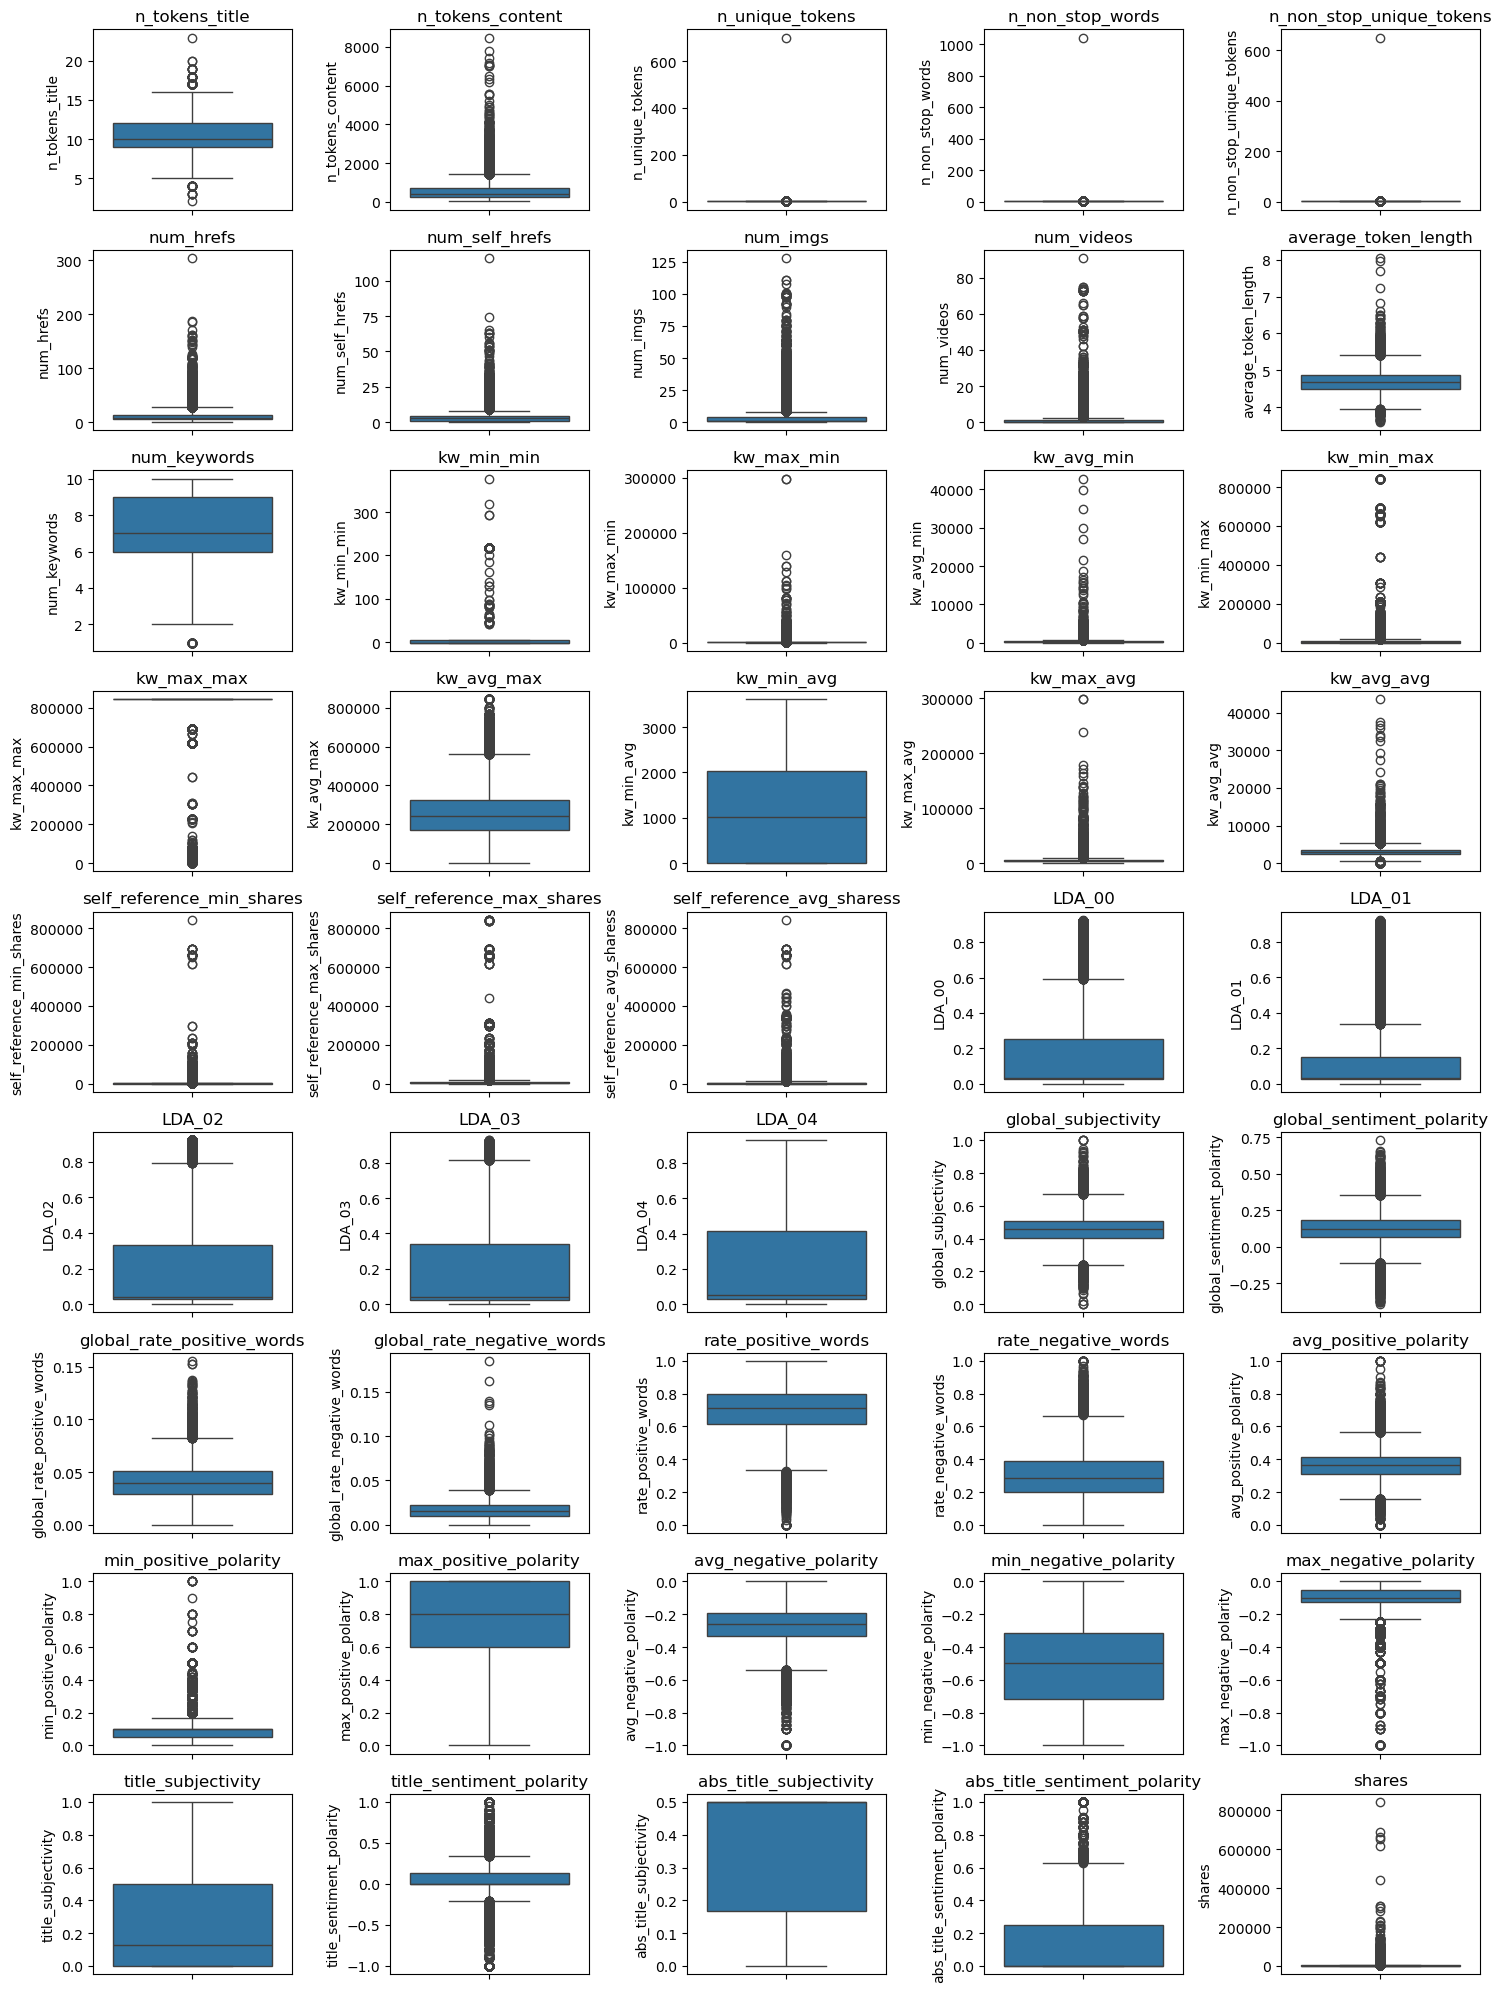

In [16]:
# Determine the number of columns and rows for subplots
num_cols = 5  
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols  

# Create a figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 20))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over the numeric columns and create boxplots
for i, col in enumerate(numeric_cols):
    ax = axes[i] if i < len(numeric_cols) else None  # Handle the case when there are fewer columns than subplots
    # Create the boxplot using seaborn
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)

# Adjust the spacing between subplots
fig.tight_layout()

In [17]:
# histogram plotting function with KDE overlay 
# plot mean as a red line 
def generate_histograms(df, numeric_cols):
    for col in numeric_cols:
        sns.histplot(df[col], kde=True, color='blue')
        plt.title(col, fontsize=18)
        plt.xlabel(col, fontsize=16)
        plt.ylabel('Frequency', fontsize=16)
        mean = df[col].mean()
        plt.axvline(mean, color='red')
        plt.show()

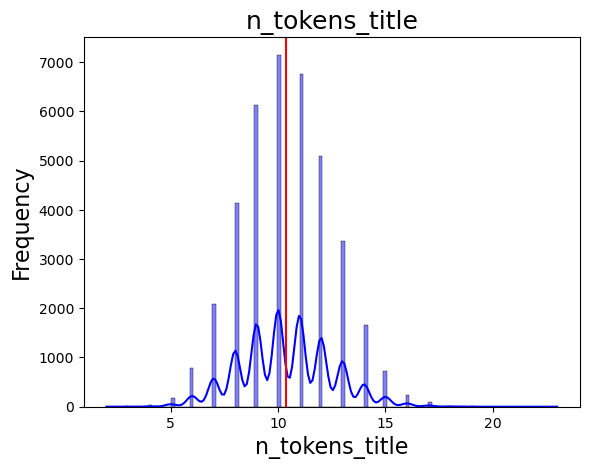

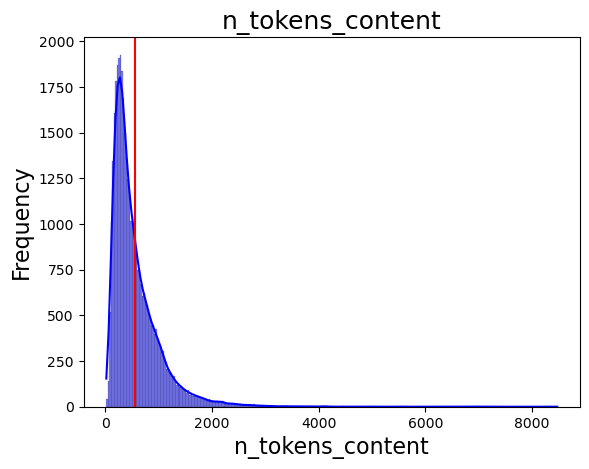

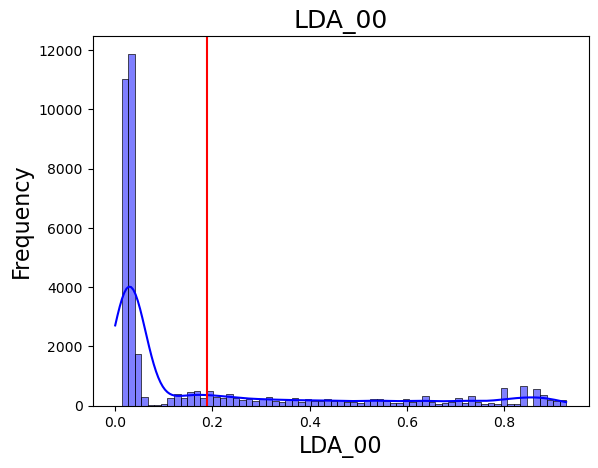

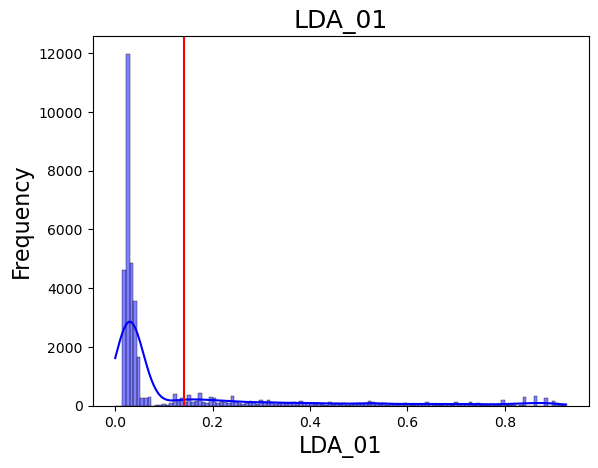

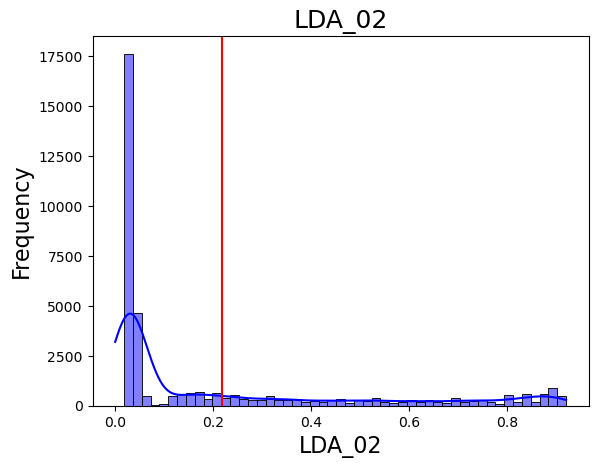

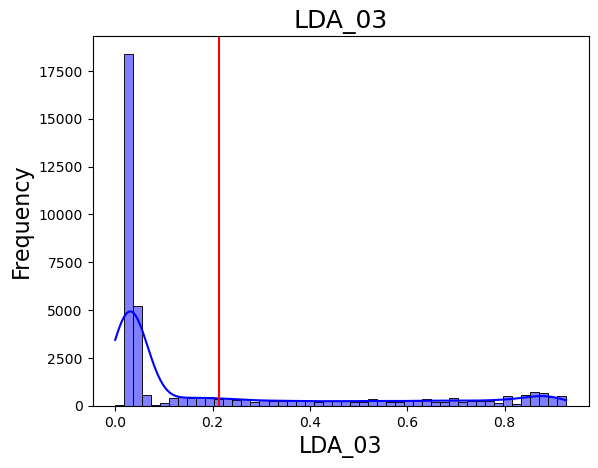

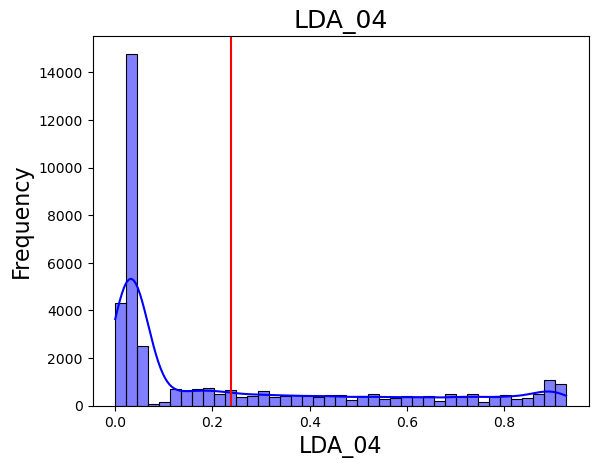

In [18]:
# due to kernel constraints, I selected a sub sample of numeric fields to plot
sub_numeric_cols = ['n_tokens_title', 'n_tokens_content', 'LDA_00', 'LDA_01', 'LDA_02','LDA_03', 'LDA_04']
generate_histograms(df, sub_numeric_cols)

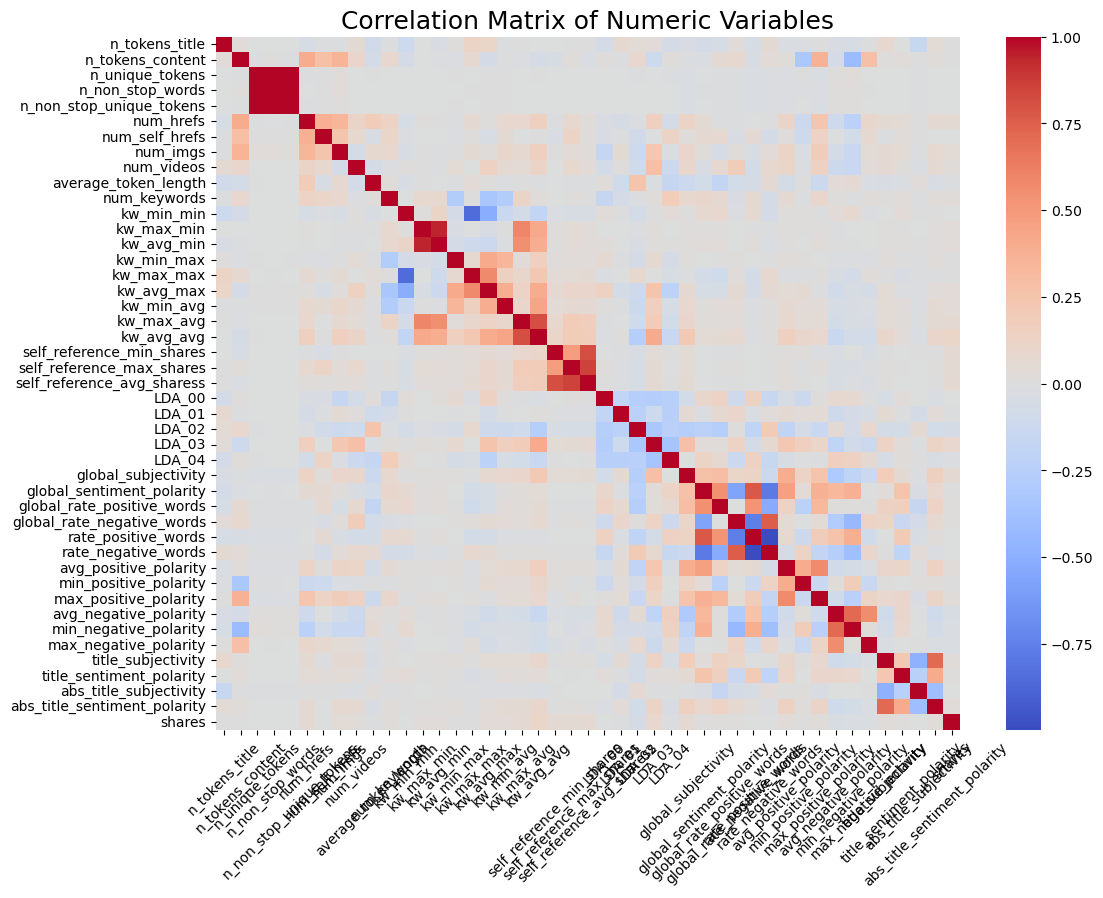

In [19]:
# Calculate the correlation matrix
correlation = df[numeric_cols].corr()

# Create a figure and axis with a larger size
fig, ax = plt.subplots(figsize=(12, 9))

# Create the heatmap
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns, ax=ax, cmap="coolwarm")

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Set the title and labels
ax.set_title("Correlation Matrix of Numeric Variables", fontsize=18);

In [20]:
df = df.drop(['n_non_stop_words','n_unique_tokens','kw_avg_min','kw_avg_avg'],axis=1)

In [21]:
df.columns

Index(['n_tokens_title', 'n_tokens_content', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'kw_min_min', 'kw_max_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03',
       'LDA_04', 'global_subjectivity', 'global_sentiment_polarity',
       'global_rate_positive_words', 'global_rate_negative_words',
       'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity',
       'min_positive_polarity', 'max_positive_polarity',
       'avg_negative_polarity', 'min_negative_polarity',
       'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'shares', 'data_channel', 'weekday_is'],
      dtype='object')

In [22]:
numeric_cols = ['n_tokens_title', 'n_tokens_content', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'kw_min_min', 'kw_max_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03',
       'LDA_04', 'global_subjectivity', 'global_sentiment_polarity',
       'global_rate_positive_words', 'global_rate_negative_words',
       'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity',
       'min_positive_polarity', 'max_positive_polarity',
       'avg_negative_polarity', 'min_negative_polarity',
       'max_negative_polarity', 'title_subjectivity',
       'title_sentiment_polarity', 'abs_title_subjectivity',
       'abs_title_sentiment_polarity', 'shares']

##### Categorical Factors

In [23]:
# barplot function  
def bar_plot(x, df, order=None):
    count = df[x].value_counts()
    # Reorder the count based on the provided order
    if order:
        count = count.reindex(order)
    sns.barplot(x=count.index, y=count.values, alpha=0.8)
    plt.title(x, fontsize=18)
    plt.xlabel(x, fontsize=16)
    plt.ylabel('Number of Occurrences', fontsize=16)
    # Add count labels to each bar
    for i, v in enumerate(count.values):
        plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)
    plt.show();

In [24]:
categorical_cols = ['data_channel', 'weekday_is']
weekdays_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

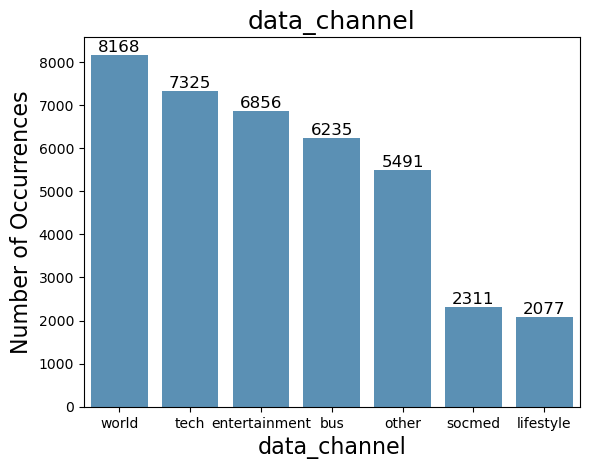

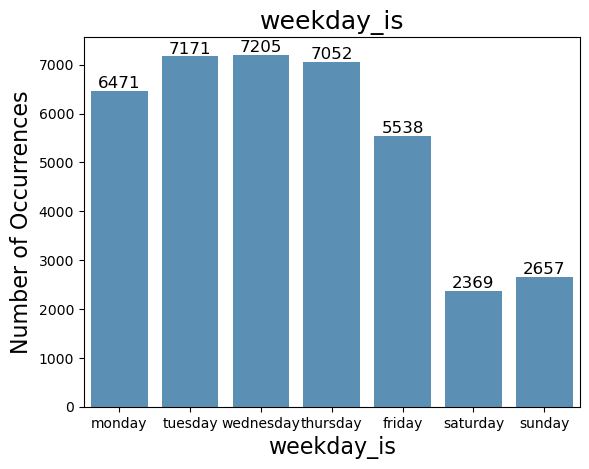

In [25]:
for col in categorical_cols:
    if col == "weekday_is":
        bar_plot(col, df, weekdays_order)
    else:
        bar_plot(col, df)

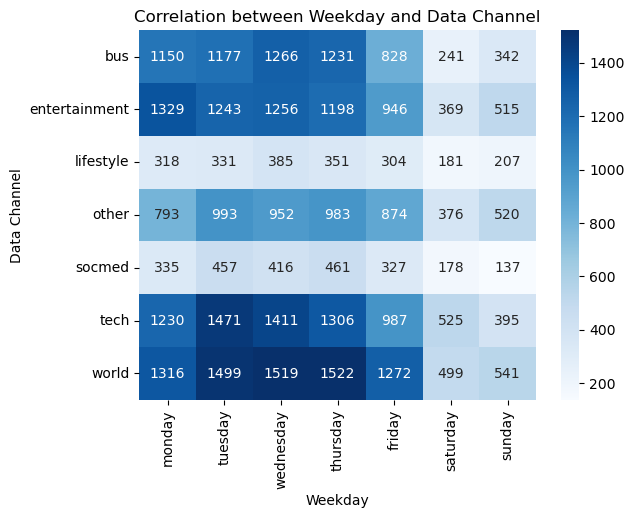

In [26]:
# create a heatmap to visualize the correlation between weekday and data channel variables
# each cell represents the count of articles corresponding to a specific combination of weekday and data channel

weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
cross_tab = pd.crosstab(df['data_channel'], df['weekday_is'])
cross_tab = cross_tab.reindex(weekday_order, axis=1)

sns.heatmap(cross_tab, cmap='Blues', annot=True, fmt='d')
plt.title('Correlation between Weekday and Data Channel')
plt.xlabel('Weekday')
plt.ylabel('Data Channel')
plt.show()

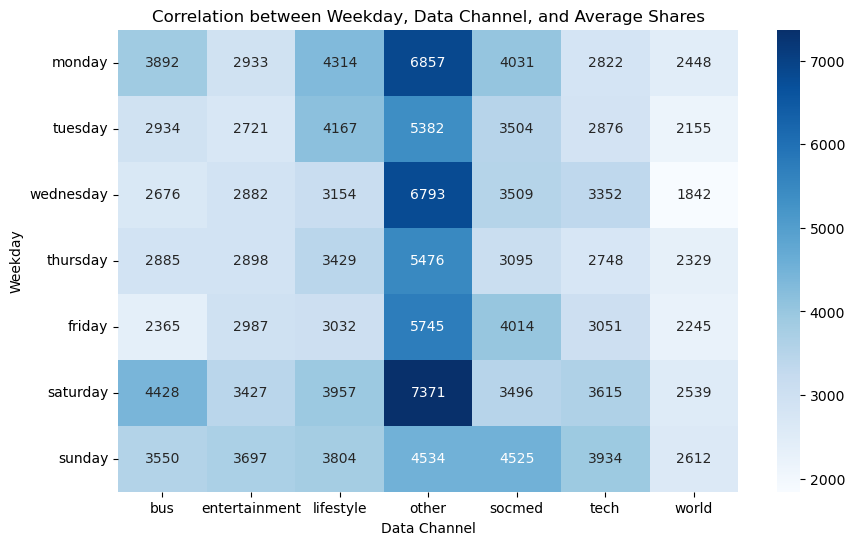

In [27]:
# create a heatmap to visualize the correlation between weekday, data channel variables, and avg shares

# calculate the average number of shares for each combination of weekday and data channel
pivot_table = df.pivot_table(index='weekday_is', columns='data_channel', values='shares', aggfunc='mean', fill_value=0)

# reorder the rows of the pivot table based on weekday_order
pivot_table = pivot_table.reindex(weekday_order)

# create heatmap - color intensity is based on average shares
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, cmap='Blues', annot=True, fmt='.0f')
plt.title('Correlation between Weekday, Data Channel, and Average Shares')
plt.xlabel('Data Channel')
plt.ylabel('Weekday')
plt.show()

##### Remove Outliers

In [28]:
for column in numeric_cols:
    q1 = df[column].quantile(0.25)  # First Quartile
    q3 = df[column].quantile(0.75)  # Third Quartile
    IQR = q3 - q1  # Interquartile Range

    llimit = q1 - 1.5 * IQR  # Lower Limit
    ulimit = q3 + 1.5 * IQR  # Upper Limit

    outliers = df[(df[column] < llimit) | (df[column] > ulimit)]
    print('Number of outliers in "' + column + '": ' + str(len(outliers)))
    print('Lower Limit:', llimit)
    print('Upper Limit:', ulimit)
    print('Interquartile Range (IQR):', IQR)

Number of outliers in "n_tokens_title": 155
Lower Limit: 4.5
Upper Limit: 16.5
Interquartile Range (IQR): 3.0
Number of outliers in "n_tokens_content": 1875
Lower Limit: -446.0
Upper Limit: 1434.0
Interquartile Range (IQR): 470.0
Number of outliers in "n_non_stop_unique_tokens": 657
Lower Limit: 0.4460529840195001
Upper Limit: 0.9434793143915
Interquartile Range (IQR): 0.12435658259299998
Number of outliers in "num_hrefs": 2636
Lower Limit: -8.5
Upper Limit: 27.5
Interquartile Range (IQR): 9.0
Number of outliers in "num_self_hrefs": 2090
Lower Limit: -3.5
Upper Limit: 8.5
Interquartile Range (IQR): 3.0
Number of outliers in "num_imgs": 7466
Lower Limit: -3.5
Upper Limit: 8.5
Interquartile Range (IQR): 3.0
Number of outliers in "num_videos": 2939
Lower Limit: -1.5
Upper Limit: 2.5
Interquartile Range (IQR): 1.0
Number of outliers in "average_token_length": 552
Lower Limit: 3.9477737410249993
Upper Limit: 5.410377035785
Interquartile Range (IQR): 0.36565082369000024
Number of outliers in

In [29]:

def create_strip_plots(data, numeric_cols):
    # Determine the number of rows and columns for the subplots
    n_rows = (len(numeric_cols) - 1) // 4 + 1
    n_cols = min(len(numeric_cols), 4)

    # Create the subplots with the appropriate number of rows and columns
    fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(30, 40))
    plt.subplots_adjust(hspace=0.4)

    # Iterate over the numeric columns and create strip plots
    for i, column in enumerate(numeric_cols):
        row = i // n_cols
        col = i % n_cols
        sns.stripplot(data[column], jitter=True, alpha=0.3, ax=ax[row][col])
        ax[row][col].set_xlabel(column)

    plt.show()

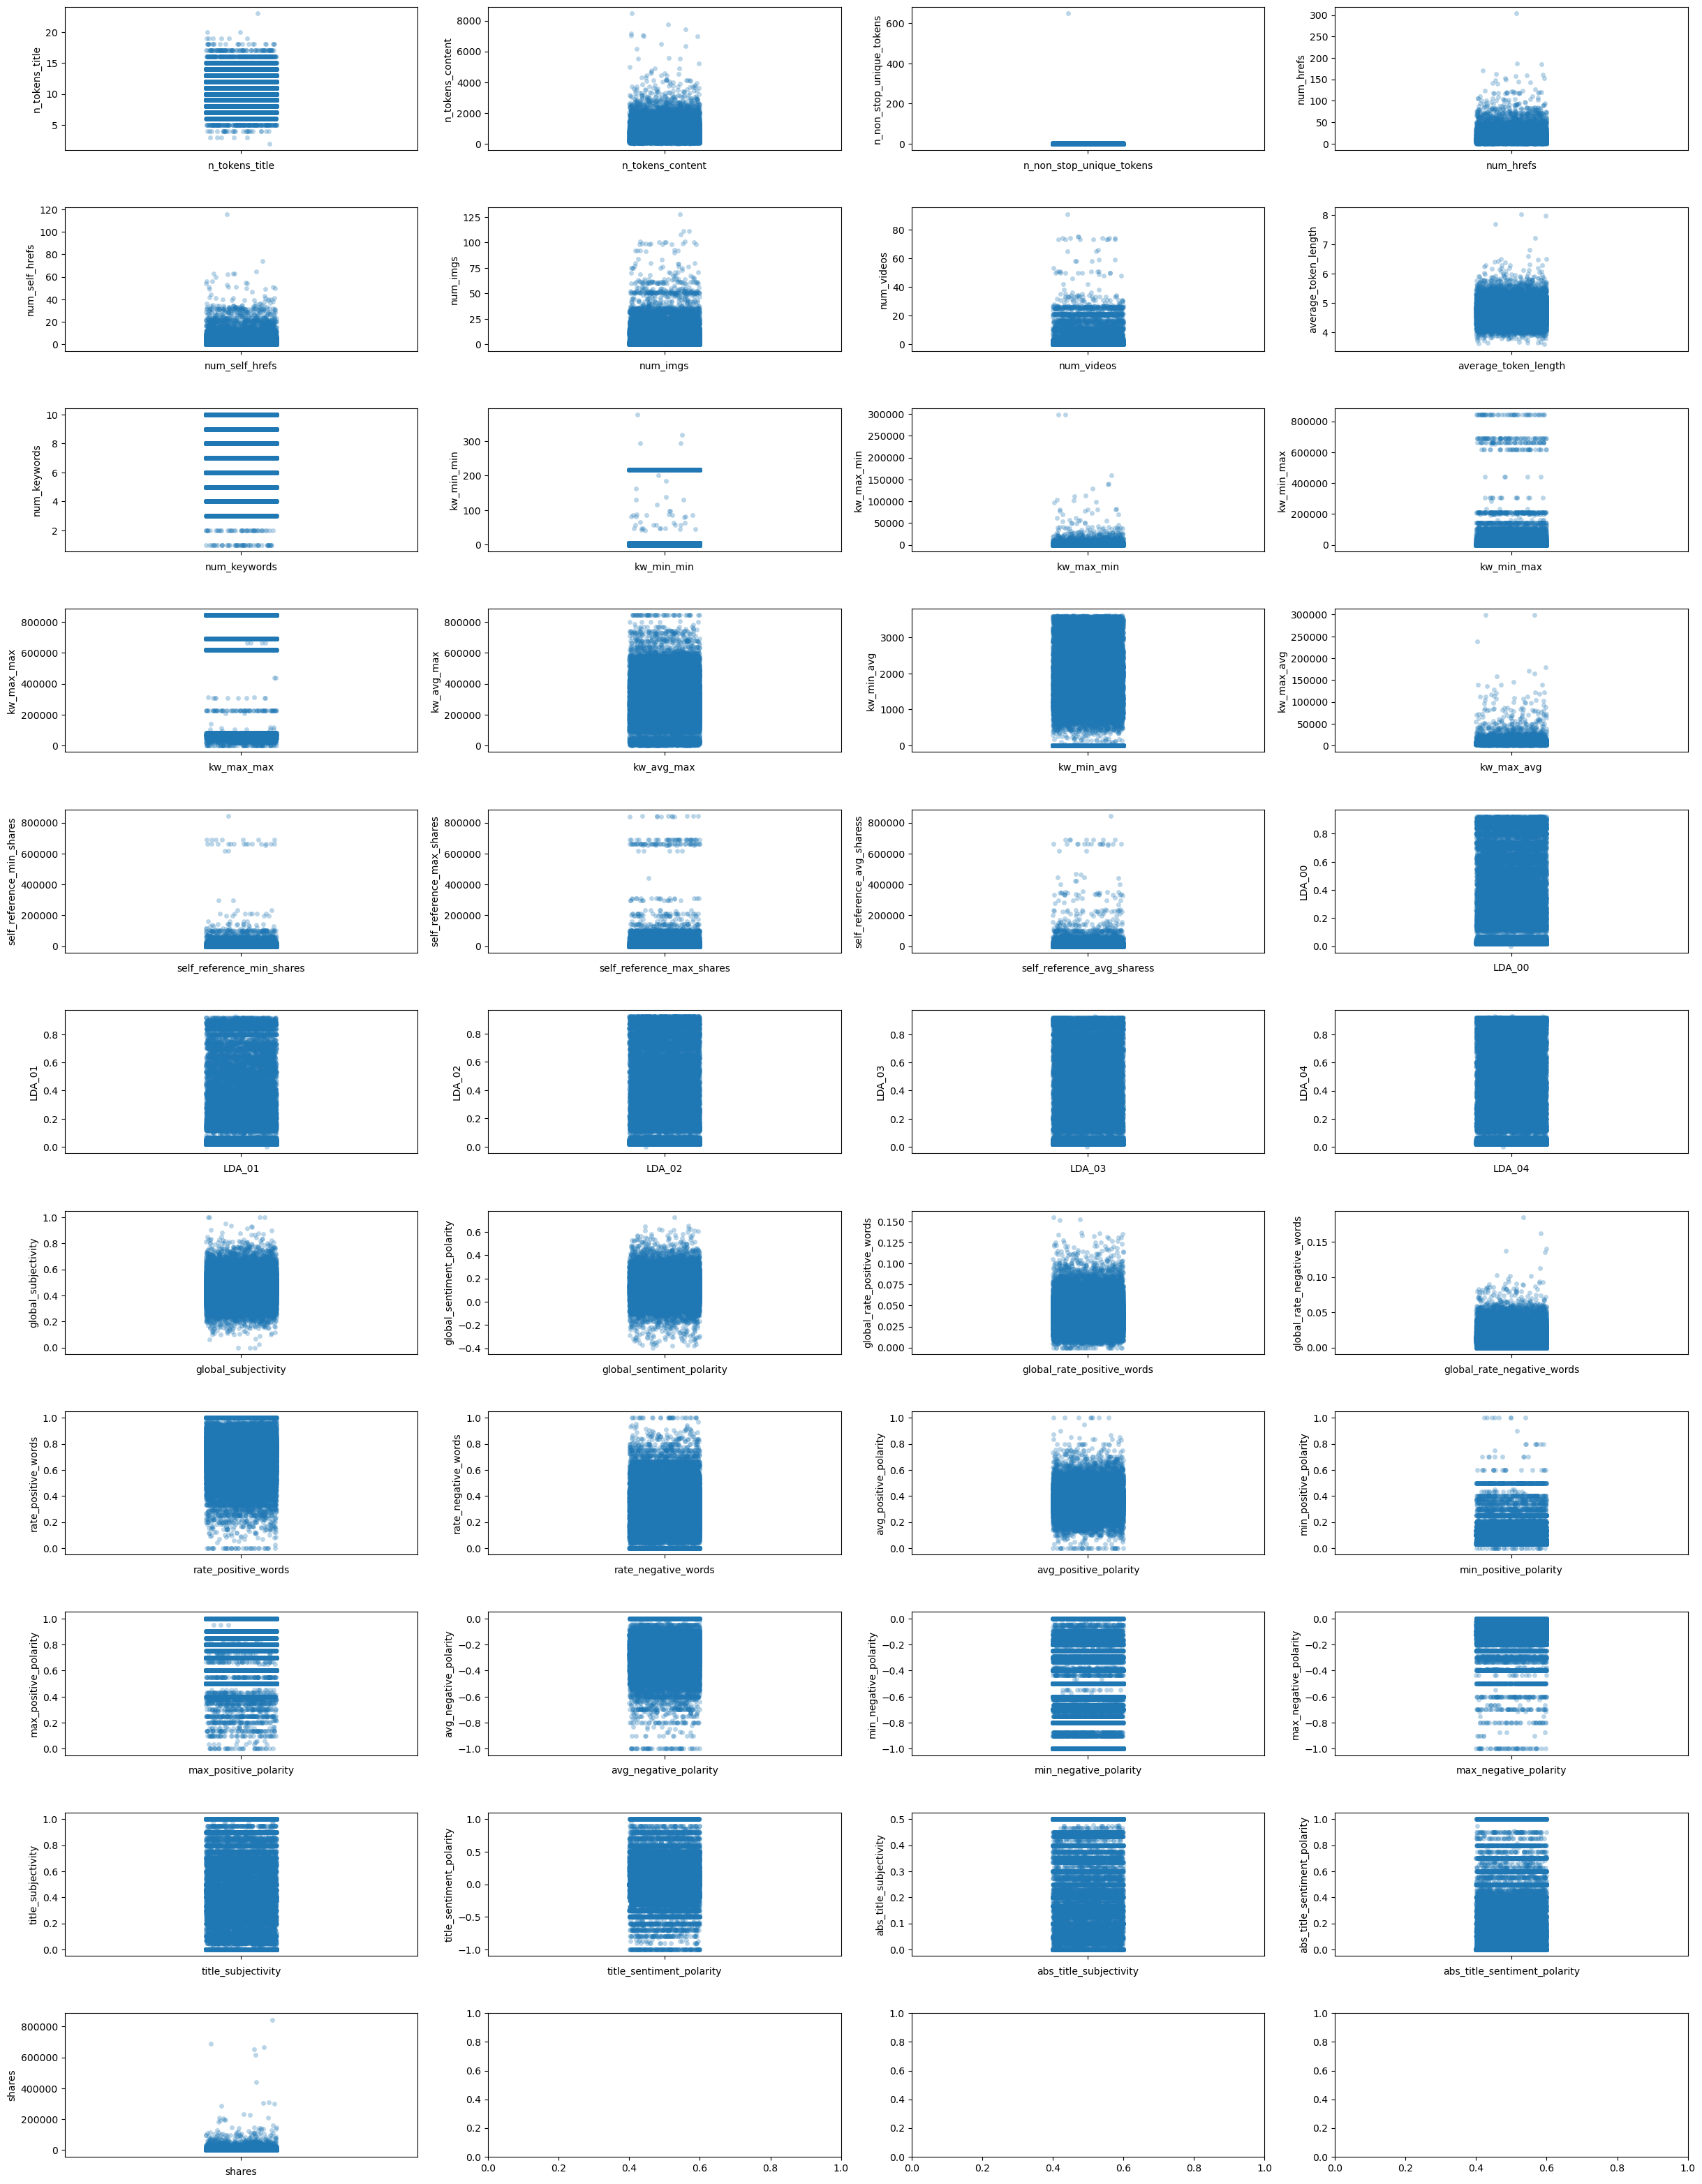

In [30]:
create_strip_plots(df, numeric_cols)

In [31]:
filtered_df = df[df['shares'] >= 150000]
count = len(filtered_df)
print("Number of articles with 150,000 or more shares:", count)

Number of articles with 150,000 or more shares: 20


In [32]:
df = df[df['shares'] < 150000]
print("Dataframe row count decreased from 38,463 to", len(df.index))

Dataframe row count decreased from 38,463 to 38443


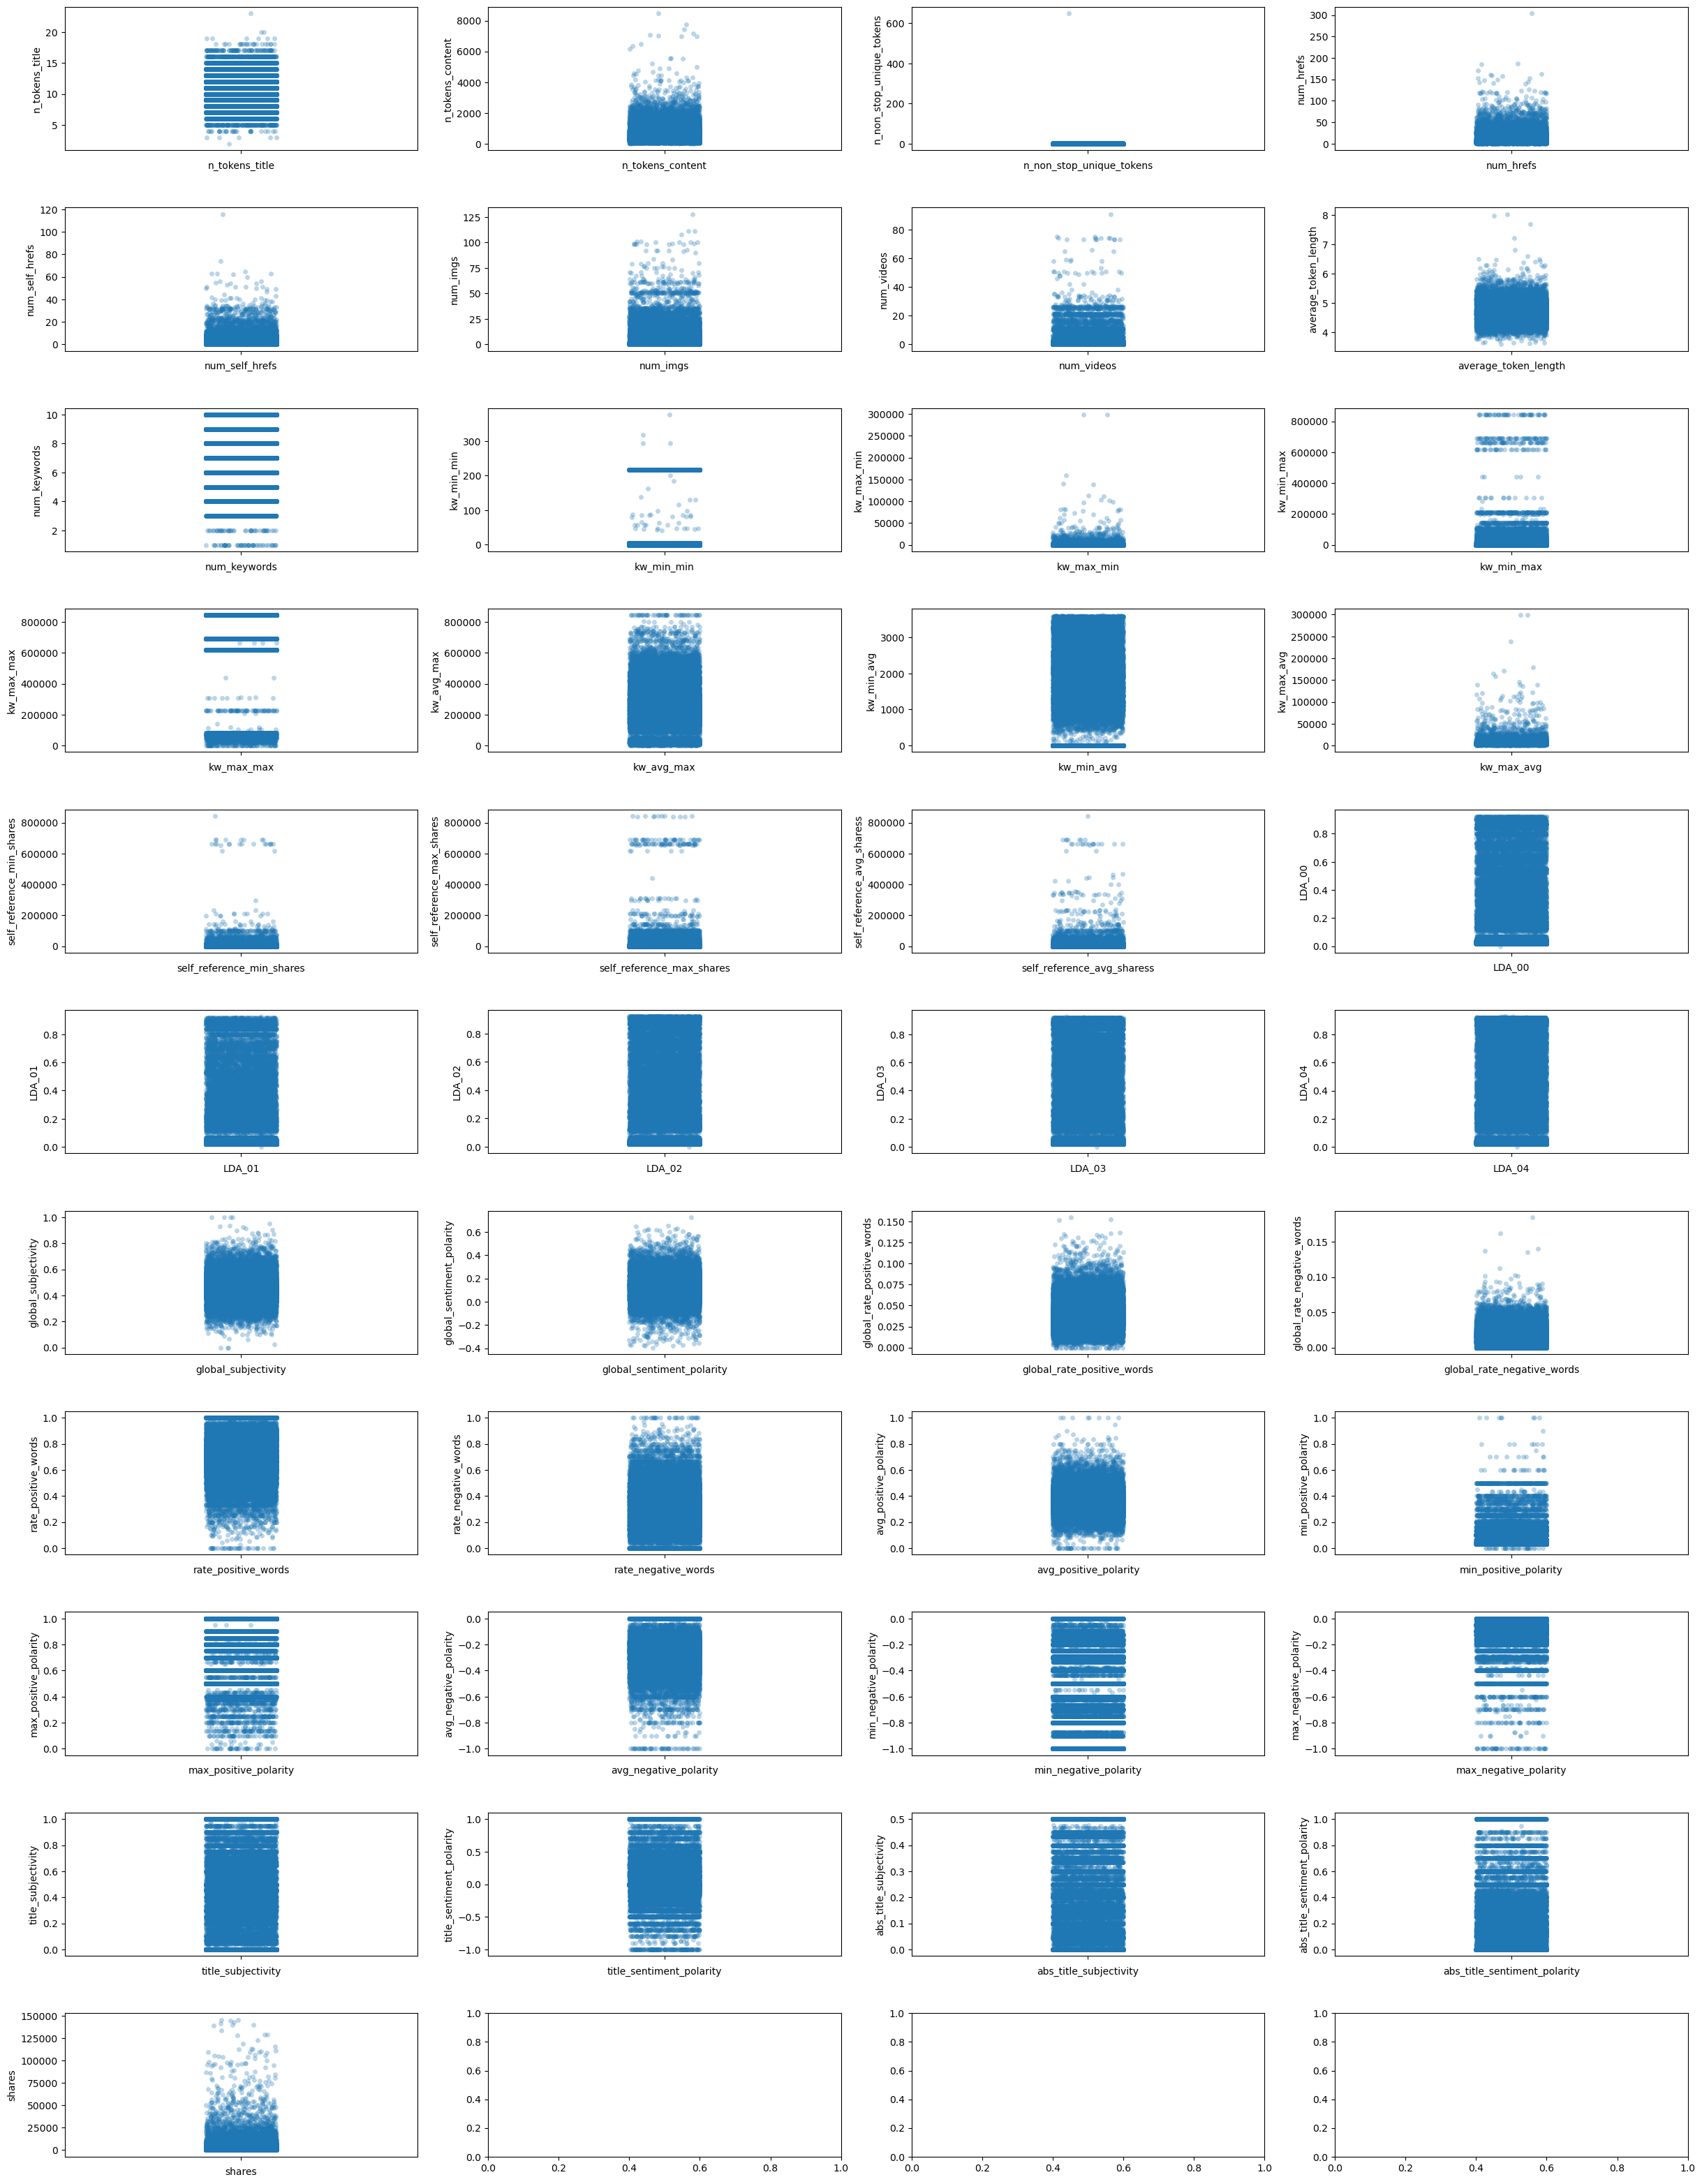

In [33]:
create_strip_plots(df, numeric_cols)

##### Data Type Munging

In [34]:
# define a dictionary mapping weekdays to numeric values
weekday_mapping = {
    'monday': 1,
    'tuesday': 2,
    'wednesday': 3,
    'thursday': 4,
    'friday': 5,
    'saturday': 6,
    'sunday': 7
}

# map the weekday_is column using the defined mapping
df['weekday_is'] = df['weekday_is'].map(weekday_mapping)

In [35]:
# Create a dictionary mapping data channels to numeric values
channel_mapping = {
    'lifestyle': 1,
    'entertainment': 2,
    'bus': 3,
    'socmed': 4,
    'tech': 5,
    'world': 6,
    'other': 7
}
# map the data_channel column using the defined mapping
df['data_channel'] = df['data_channel'].map(channel_mapping).astype(int)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38443 entries, 0 to 39643
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   n_tokens_title                38443 non-null  float64
 1   n_tokens_content              38443 non-null  float64
 2   n_non_stop_unique_tokens      38443 non-null  float64
 3   num_hrefs                     38443 non-null  float64
 4   num_self_hrefs                38443 non-null  float64
 5   num_imgs                      38443 non-null  float64
 6   num_videos                    38443 non-null  float64
 7   average_token_length          38443 non-null  float64
 8   num_keywords                  38443 non-null  float64
 9   kw_min_min                    38443 non-null  float64
 10  kw_max_min                    38443 non-null  float64
 11  kw_min_max                    38443 non-null  float64
 12  kw_max_max                    38443 non-null  float64
 13  kw_avg

In [37]:
# make sure it has no null values 
df.isnull().sum()

n_tokens_title                  0
n_tokens_content                0
n_non_stop_unique_tokens        0
num_hrefs                       0
num_self_hrefs                  0
num_imgs                        0
num_videos                      0
average_token_length            0
num_keywords                    0
kw_min_min                      0
kw_max_min                      0
kw_min_max                      0
kw_max_max                      0
kw_avg_max                      0
kw_min_avg                      0
kw_max_avg                      0
self_reference_min_shares       0
self_reference_max_shares       0
self_reference_avg_sharess      0
LDA_00                          0
LDA_01                          0
LDA_02                          0
LDA_03                          0
LDA_04                          0
global_subjectivity             0
global_sentiment_polarity       0
global_rate_positive_words      0
global_rate_negative_words      0
rate_positive_words             0
rate_negative_

In [38]:
# save a copy of the cleaned dataframe to a CSV file
df.to_csv('df_cleaned.csv', index=False)